In [1]:
# 전체 패키지 설치
!pip install -q langchain langchain-core langchain-openai langchain-community langchain-text-splitters

# 추가 유용한 패키지들
!pip install -q faiss-cpu tiktoken python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 61.0 MB/s eta 0:00:00


In [3]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get("kosa")

프롬프트
  - 사용자와 언어 모델간의 대화에서 질문이나 요청의 형태로 제시되는 입력문이다
  - 모델이 어떤 유형의 응답을 제공할지 결정하는데 중요한 역할을 한다
  - 프롬프트 작성원칙
    1. 명확성과 구체성 : 질문은 명확하고 구체적이어야 한다
    2. 배경 정보를 포함 : 모델이 문맥을 이해할 수 있도록 필요한 배경정보를 제공하는 것이 좋다 -> 환각현상이 발생할 위험을 낮추고, 관련성 높은 응답을 생성하는데 도움이 된다
    3. 간결함 : 핵심정보에 초점을 맞추고, 불필요한 정보는 배제한다
    4. 열린 질문 사용 : 모델이 자세하고 풍부한 답변을 제공하도록 유도한다
    5. 명확한 목표 설정 : 얻고자하는 정보나 결과의 유형을 정확하게 정의한다
    6. 언어와 문체 : 대화의 맥락에 적합한 언어와 문체를 선택한다

프롬프트 템플릿
  - 단일 문장 또는 간단한 명령을 입력하여 단일 문장 또는 간단한 응답을 생성
  - 구성요소 : LLM 모델에 입력할 프롬프트를 구성할 때
    1. 지시 : 모델에게 어떤 작업을 수행하도록 요청
    2. 예시 : 요청된 작업을 수행하는 방법에 대한 하나 이상의 예시
    3. 맥락 : 특정 작업을 수행하기 위한 추가적인 맥락
    4. 질문 : 어떤 답변을 요구하는 구체적인 질문

In [4]:
# 문자열 템플릿
from langchain_core.prompts import PromptTemplate

tmp_txt = '안녕하세요. 내 이름은 {name}이고, 나이는 {age}살 입니다.'

prompt_tmp = PromptTemplate.from_template(tmp_txt)

filled_prompt = prompt_tmp.format(name='홍길동', age=20)

filled_prompt

'안녕하세요. 내 이름은 홍길동이고, 나이는 20살 입니다.'

In [5]:
# 프롬프트 템플릿간의 결합

combined_prompt = (
    prompt_tmp
    + PromptTemplate.from_template('\n\n아버지를 아버지라 부르지 못한다')
    + '\n\n{language}로 번역해줘'
)

combined_prompt

PromptTemplate(input_variables=['age', 'language', 'name'], input_types={}, partial_variables={}, template='안녕하세요. 내 이름은 {name}이고, 나이는 {age}살 입니다.\n\n아버지를 아버지라 부르지 못한다\n\n{language}로 번역해줘')

In [6]:
print(combined_prompt.format(name='홍길동', age=20, language='영어'))

안녕하세요. 내 이름은 홍길동이고, 나이는 20살 입니다.

아버지를 아버지라 부르지 못한다

영어로 번역해줘


In [7]:
# ChatOpenAi 인스턴스 생성하여 프롬프트 텍스트 전달 후 출력

from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(model='gpt-4o-mini')
chain = combined_prompt | llm | StrOutputParser()

print(chain.invoke({'name':'홍길동', 'age':20, 'language':'영어'}))


안녕하세요, 홍길동님. 요청하신 문장을 영어로 번역해 드리겠습니다.

"I cannot call my father 'father'."


챗 프롬프트 템플릿
  - 대화형 상황에서 여러 메시지 기반으로 단일메시지 응답을 생성하는데 사용
  - 입력은 여러 메시지를 원소로 갖는리스트로 구성되고, 각 메시지는 role(역할)과 content(내용)으로 구성됨

LangChain에서 assist라는 명령어나 모듈은 없지만, LLM을 보조 도구로 사용하는 방식

In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 모델 생성
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3
)

# 프롬프트 정의
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 숙련된 기술 문서 작성자야.

개발자를 위한 문서를 Markdown 형식으로 작성해.

구조:

## 개요

## 핵심 개념

## 코드 예제

## 참고 자료

항상 한국어로 작성해.
"""
    ),
    ("human", "{topic}")
])

# 체인 생성
chain = prompt | llm

# 질문
topic = "LangChain의 LLMChain 구성 요소 설명해줘"

# 스트리밍 출력
for chunk in chain.stream({
    "topic": topic
}):
    print(chunk.content, end="", flush=True)


## 개요

LangChain은 자연어 처리(NLP) 애플리케이션을 구축하기 위한 프레임워크로, 다양한 언어 모델(LLM)과의 통합을 지원합니다. LLMChain은 LangChain의 핵심 구성 요소 중 하나로, 언어 모델과 그에 대한 입력 및 출력을 연결하는 역할을 합니다. 이 문서에서는 LLMChain의 구성 요소와 기능에 대해 설명합니다.

## 핵심 개념

### LLMChain

LLMChain은 다음과 같은 주요 구성 요소로 이루어져 있습니다:

1. **LLM (Language Model)**: 자연어 처리 작업을 수행하는 모델입니다. 예를 들어, OpenAI의 GPT-3 또는 GPT-4와 같은 모델이 여기에 해당합니다.

2. **프롬프트 (Prompt)**: LLM에 입력으로 제공되는 텍스트입니다. 프롬프트는 모델이 이해할 수 있도록 정보를 구조화하는 방법입니다.

3. **출력 (Output)**: LLM이 프롬프트에 대한 응답으로 생성하는 텍스트입니다. 이는 사용자가 원하는 정보나 결과를 포함할 수 있습니다.

4. **체인 (Chain)**: LLMChain은 여러 개의 프롬프트와 출력을 연결하여 복잡한 작업을 수행할 수 있도록 합니다. 예를 들어, 여러 단계의 질문과 답변을 포함하는 체인을 구성할 수 있습니다.

### LLMChain의 작동 방식

1. 사용자가 입력한 프롬프트가 LLMChain에 전달됩니다.
2. LLM은 프롬프트를 처리하고 출력을 생성합니다.
3. 생성된 출력은 후속 프로세스나 사용자에게 전달됩니다.

## 코드 예제

다음은 LangChain의 LLMChain을 사용하는 간단한 코드 예제입니다.

```python
from langchain import LLMChain
from langchain.llms import OpenAI

# OpenAI LLM 초기화
llm = OpenAI(api_key='YOUR_API_KEY')

# LLMChain 구성
llm_chain = LLMChain(llm=llm, promp

In [9]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate


# 1. OpenAI LLM 설정 (GPT-4 또는 GPT-3.5 사용 가능)
llm = ChatOpenAI(temperature=0.3)

# 2. 역할 기반 프롬프트 정의
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 숙련된 기술 문서 작성자야. "
     "개발자들을 위한 문서를 마크다운 형식으로 작성해. "
     "구조는 다음과 같아:\n\n"
     "## 개요\n\n"
     "## 핵심 개념\n\n"
     "## 코드 예제\n\n"
     "## 참고 자료\n\n"
     "항상 한국어로 작성해."),
    ("human", "{topic}")
])

# 3. 체인생성
tech_doc_assistant = prompt | llm

# 4. 주제 입력 예시
topic = "LangChain의 LLMChain 구성 요소 설명해줘"

# 5. 실행
response = tech_doc_assistant.invoke({"topic": topic})

# 6. 출력
print(response.content)

## 개요
LangChain은 다양한 언어 간 번역을 지원하는 블록체인 기반의 플랫폼이다. LLMChain은 LangChain의 핵심 구성 요소 중 하나로, Language Learning Module Chain의 약자이다.

## 핵심 개념
LLMChain은 LangChain 플랫폼에서 언어 학습 모듈을 관리하고 실행하는 역할을 한다. 이를 통해 사용자들은 LangChain을 통해 다른 언어를 학습할 수 있게 된다. LLMChain은 분산화된 시스템으로 구성되어 있어, 안전하고 투명한 학습 환경을 제공한다.

## 코드 예제
```markdown
# LLMChain 구성 요소 예시

- Language Learning Module Manager: 언어 학습 모듈을 관리하는 역할
- Language Learning Module Executor: 언어 학습 모듈을 실행하는 역할
- Language Learning Module Interface: 언어 학습 모듈과 상호 작용하는 인터페이스
```

## 참고 자료
- LangChain 공식 문서: [https://langchain.com/docs](https://langchain.com/docs)
- LangChain GitHub 저장소: [https://github.com/langchain](https://github.com/langchain)


assist 흉내 낸 래퍼함수

In [10]:
# 최신 OpenAI Chat Model
from langchain_openai import ChatOpenAI

# Prompt Template
from langchain_core.prompts import ChatPromptTemplate


def simple_assist(llm, prompt_template):
    """
    assist와 비슷한 역할을 하는 간단한 래퍼 함수

    - llm: ChatOpenAI 객체
    - prompt_template: ChatPromptTemplate 객체

    반환:
        assistant 함수
    """

    # 최신 LangChain 방식 (LCEL)
    chain = prompt_template | llm

    # assistant 함수 정의
    # helper(wrapper) 함수
    def assistant(inputs: dict) -> str:

        # invoke 실행
        response = chain.invoke(inputs)

        # AIMessage 객체에서 content 추출
        return response.content

    return assistant


# 메인 실행
if __name__ == "__main__":

    # LLM 생성
    llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0.3
    )

    # Prompt 생성
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "너는 친절한 기술문서 작성자야. "
                "마크다운 형식으로 상세하게 작성해줘."
            ),

            (
                "human",
                "{topic}"
            )
        ]
    )

    # assistant 생성
    tech_doc_assistant = simple_assist(llm, prompt)

    # 호출
    result = tech_doc_assistant(
        {
            "topic": "LangChain의 LLMChain에 대해 설명해주고 간단한 코드 예제도 보여줘."
        }
    )

    # 출력
    print(result)

# LangChain의 LLMChain

## 개요
LangChain은 자연어 처리(NLP) 및 대화형 AI 애플리케이션을 구축하기 위한 프레임워크입니다. 이 프레임워크의 핵심 구성 요소 중 하나인 `LLMChain`은 대규모 언어 모델(LLM)과 상호작용하는 체인을 구성하는 데 사용됩니다. `LLMChain`은 입력을 받아 LLM을 호출하고, 그 결과를 처리하여 최종 출력을 생성하는 일련의 단계를 정의합니다.

## 주요 기능
- **모듈화**: 각 단계가 독립적으로 구성되어 있어, 필요에 따라 쉽게 수정하거나 교체할 수 있습니다.
- **유연성**: 다양한 LLM과 함께 사용할 수 있으며, 사용자 정의 로직을 추가할 수 있습니다.
- **간단한 인터페이스**: 복잡한 작업을 간단한 메서드 호출로 수행할 수 있습니다.

## 사용 예시
아래는 LangChain의 `LLMChain`을 사용하는 간단한 코드 예제입니다. 이 예제에서는 사용자의 질문에 대해 LLM이 답변하도록 설정합니다.

### 코드 예제

```python
from langchain import LLMChain
from langchain.llms import OpenAI

# OpenAI LLM 초기화
llm = OpenAI(api_key='YOUR_API_KEY')

# LLMChain 생성
chain = LLMChain(llm=llm)

# 사용자 질문
user_input = "AI의 미래는 어떻게 될까요?"

# LLMChain을 사용하여 답변 생성
response = chain.run(user_input)

# 결과 출력
print("AI의 미래에 대한 답변:", response)
```

### 코드 설명
1. **OpenAI LLM 초기화**: `OpenAI` 클래스를 사용하여 LLM을 초기화합니다. API 키를 제공해야 합니다.
2. **LLMChain 생성**: `LLMChain` 객체를 생성하고, 초기화한 LLM을 전달합니다.
3. **사용자 질문**: 사용자가 입력한 질문을 

Chatgpt 같은 일반 어시스턴트를 LangChain으로 구현
- OpenAI + ConversationBufferMemory + Gradio UI

In [11]:
# 라이브러리 import
import os
import gradio as gr

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage


# OpenAI API 키 설정
# os.environ["OPENAI_API_KEY"] = "여기에_API_KEY_입력"


# LLM 모델 생성
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)


# Gradio UI 응답 함수
def respond(message, chat_history):
    """
    message: 사용자가 입력한 현재 메시지
    chat_history: Gradio가 저장하는 이전 대화 기록
    """

    # LangChain 메시지 형식으로 변환
    messages = [
        SystemMessage(content="너는 친절한 한국어 AI assistant야.")
    ]

    # 이전 대화 기록 추가
    for user_msg, bot_msg in chat_history:
        messages.append(HumanMessage(content=user_msg))
        messages.append(AIMessage(content=bot_msg))

    # 현재 사용자 메시지 추가
    messages.append(HumanMessage(content=message))

    # LLM 호출
    response = llm.invoke(messages)

    # 챗봇 기록에 추가
    chat_history.append((message, response.content))

    return "", chat_history


# Gradio 화면 구성
with gr.Blocks() as demo:
    gr.Markdown("## LangChain Assistant (GPT 스타일)")

    chatbot = gr.Chatbot()
    msg = gr.Textbox(
        placeholder="메시지를 입력하세요...",
        label="입력"
    )

    msg.submit(
        respond,
        inputs=[msg, chatbot],
        outputs=[msg, chatbot]
    )


demo.launch()

/tmp/ipykernel_1436/304999296.py:53: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot()
/tmp/ipykernel_1436/304999296.py:53: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://58081b913f1e41582e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


LangGraph + LangChai OpenAI 를 활용한 Assistant

In [12]:
!pip install -q langchain langchain-openai langgraph python-dotenv ipython graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.5 MB/s eta 0:00:00


In [13]:
import os
from typing import TypedDict, Annotated, List
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage

# Openai Key

# 상태 정의
class State(TypedDict):
  messages: Annotated[List, add_messages]

# messages : 중요 대화내용 기록(chat history) (key)
# Annotated[List, add_messages]
# >> List(데이터타입) 메세지 객체(HumanMessage, AImessage) 가 리스트에 들어감
# >> add_messages 새로운 메시지 입력 시 상태를 업데이트
# >> [HumanMessage, AImessage] 형태로 누적되어 저장

# 모델 생성
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.7)

# 대화 처리 노드
def assistant_node(state:State):
  response = llm.invoke(state['messages'])
  return {'messages':[response]}

# 그래프 구성
graph = StateGraph(State)

graph.add_node('assistant', assistant_node)

graph.add_edge(START, 'assistant')
graph.add_edge('assistant', END)

# 그래프 빌드
app = graph.compile()


# 대화 실행
from langchain_core.messages import HumanMessage

inputs = {'messages':[HumanMessage(content='안녕! 블랙홀에 대해 설명해줘')]}

for output in app.stream(inputs):
  print(output)

{'assistant': {'messages': [AIMessage(content='안녕하세요! 블랙홀은 우주에서 매우 강력한 중력을 가진 천체로, 그 중력이 너무 강해 빛조차도 탈출할 수 없는 영역을 형성합니다. 블랙홀은 주로 다음과 같은 두 가지 과정으로 형성됩니다.\n\n1. **별의 진화**: 대량의 별이 생애의 마지막 단계에서 핵융합 반응을 마치고, 중력에 의해 붕괴하여 블랙홀이 됩니다. 이 과정에서 별의 외부 층이 폭발하면서 초신성이 발생하고, 중심부가 블랙홀로 수축하게 됩니다.\n\n2. **중성자별의 붕괴**: 중성자별이 더 이상 중력에 대항할 수 없을 때, 중성자별이 블랙홀로 변할 수 있습니다.\n\n블랙홀은 크게 세 가지 종류로 분류됩니다:\n\n1. **스타 블랙홀(별 블랙홀)**: 일반적으로 태양의 3배에서 수십 배 정도의 질량을 가진 별이 붕괴하면서 형성됩니다.\n   \n2. **슈퍼매시브 블랙홀**: 수백만에서 수십억 배의 태양 질량을 가진 블랙홀로, 대부분의 큰 은하의 중심에 존재합니다. 예를 들어, 우리 은하인 은하수의 중심에도 슈퍼매시브 블랙홀인 \'사겔라 A*\'가 있습니다.\n\n3. **미니 블랙홀**: 이론적으로 존재할 수 있는 작은 블랙홀로, 태초의 우주에서 형성되었을 가능성이 있습니다. 그러나 현재까지 관측된 바는 없습니다.\n\n블랙홀의 경계에는 "사건의 지평선"이라는 경계가 있으며, 이 지평선을 넘어가면 어떤 정보도 외부로 나올 수 없습니다. 블랙홀의 연구는 여전히 활발히 진행 중이며, 그 특성과 영향을 이해하는 데 많은 과학자들이 노력하고 있습니다. 블랙홀에 대한 질문이 더 있거나 궁금한 점이 있다면 언제든지 물어보세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 458, 'prompt_tokens': 18, 'total_tokens': 476, 'completion_tokens_deta

saved image :  assistant_graph.png


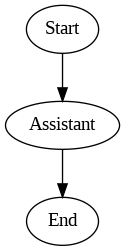

In [14]:
import graphviz
from IPython.display import Image

dot = graphviz.Digraph(comment='Workflow')

dot.node('A', 'Start')
dot.node('B', 'Assistant')
dot.node('C', 'End')

dot.edges(['AB','BC'])

filename = dot.render(filename='assistant_graph', format='png', cleanup=True)

print('saved image : ', filename)

Image(filename=filename)

In [15]:
# ChatPromptTemplate

from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model = 'gpt-4o-mini')

chat_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', '이 시스템은 인공지능 질문에 답변을 할 수 있다'),
        ('user', '{user_input}'),
    ]
)

messages = chat_prompt.format_messages(user_input = '인공지능에서 가장 발달된 기술은 무엇인가요?')
messages

[SystemMessage(content='이 시스템은 인공지능 질문에 답변을 할 수 있다', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='인공지능에서 가장 발달된 기술은 무엇인가요?', additional_kwargs={}, response_metadata={})]

In [16]:
chain = chat_prompt | llm | StrOutputParser()

print(chain.invoke({'user_input' : '인공지능에서 가장 발달된 기술은 무엇인가요?'}))

인공지능 분야에서 가장 발달된 기술 중 일부는 다음과 같습니다:

1. **딥 러닝(Deep Learning)**: 인공신경망을 사용하여 대량의 데이터를 처리하고 학습하는 기술로, 이미지 인식, 자연어 처리, 음성 인식 등 여러 분야에서 강력한 성능을 발휘합니다.

2. **자연어 처리(Natural Language Processing, NLP)**: 인간의 언어를 이해하고 생성하는 기술로, 번역, 문서 요약, 감정 분석 등 다양한 응용 분야에서 사용됩니다. 예를 들면, GPT와 같은 대형 언어 모델이 이 범주에 포함됩니다.

3. **강화 학습(Reinforcement Learning)**: 에이전트가 환경과 상호작용하며 최적의 행동을 학습하는 방법으로, 게임 AI, 로봇 제어 등에 널리 활용됩니다.

4. **생성적 적대 신경망(Generative Adversarial Networks, GANs)**: 두 개의 신경망이 서로 경쟁하여 고품질의 새로운 데이터를 생성하는 기술로, 이미지 생성, 스타일 변환 등에서 혁신적인 결과를 보여주고 있습니다.

5. **컴퓨터 비전(Computer Vision)**: 이미지나 비디오를 분석하고 이해하는 기술로, 자율주행차, 얼굴 인식, 의료 이미지 분석 등 다양한 분야에 응용되고 있습니다.

이 외에도 인공지능의 발전은 계속되고 있으며, 새로운 기술과 접근법이 지속적으로 발전하고 있습니다.


MessagePromptTemplate
  - SystemMessagePromptTemplate : 시스템 메시지 템플릿
  - HumanMessagePromptTemplate : 사용자 메시지 템플릿

In [17]:
from langchain_core.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate

llm = ChatOpenAI(model = 'gpt-4o-mini')

chat_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template('이 시스템은 인공지능질문에 답변을 할 수 있다.'),
        HumanMessagePromptTemplate.from_template('{user_input}')
    ]
)

chain = chat_prompt | llm | StrOutputParser()
print(chain.invoke({'user_input':'현재 자율주행자동차의 기술 수준은 어떤가요?'}))

현재 자율주행 자동차 기술은 빠르게 발전하고 있으며, 다양한 수준의 자율주행 기능이 상용화되고 있습니다. 일반적으로 자율주행 기술은 SAE (Society of Automotive Engineers)에서 정의한 다섯 가지 수준으로 구분됩니다.

1. **레벨 0 (No Automation)**: 운전자가 모든 주행 작업을 담당하며, 차량에는 운전 보조 기능(예: 경고 시스템)만 있음.
  
2. **레벨 1 (Driver Assistance)**: 특정 조건에서 운전 보조 시스템(예: 어댑티브 크루즈 컨트롤, Lane Keeping Assist)이 존재하지만, 운전자가 모든 주행 작업을 계속해야 함.

3. **레벨 2 (Partial Automation)**: 차량이 주행과 제어를 동시에 수행할 수 있지만, 운전자가 항상 주의를 기울이고 필요할 때를 대비해야 함(예: 테슬라의 오토파일럿).

4. **레벨 3 (Conditional Automation)**: 특정 조건에서 차량이 완전한 제어를 하며, 운전자가 주행 중 다른 작업을 수행할 수 있으나, 긴급 상황에서 운전자가 개입해야 함.

5. **레벨 4 (High Automation)**: 특정 환경이나 조건에서 차량이 완전히 자율적으로 주행할 수 있으며, 인간의 개입이 필요 없는 경우도 있음(예: 도시 내 자율주행 셔틀).

6. **레벨 5 (Full Automation)**: 모든 주행 상황에서 완전한 자율주행이 가능하며, 인간 운전자가 필요 없고 설정도 필요 없음.

현재 많은 회사들이 레벨 2 및 3 기술을 상용화하고 있으며, 레벨 4에 가까운 기술도 일부 특정 지역(예: 자율주행 택시 서비스 등)에서 테스트되고 있습니다. 하지만 레벨 5는 기술적, 법적, 윤리적 문제로 인해 상용화에 이르지 못한 상태입니다.

또한, 자율주행 기술은 인공지능, 센서 기술(예: 라이다, 카메라), 데이터 처리 능력에 많이 의존하고 있으며, 많은 기업들이 이 기술의 상용화와 안전성 향상을 위해 연구개발에 집중하고 있

In [18]:
# 최신 PromptTemplate import
from langchain_core.prompts import PromptTemplate

# 메시지 객체
from langchain_core.messages import HumanMessage

# OpenAI Chat Model
from langchain_openai import ChatOpenAI


# 프롬프트 템플릿 정의
template = """
You are a professional chef.

I recommend dishes that can be made with the ingredients I have.

Please provide:
1. Dish name
2. Recipe
3. Cooking steps

The ingredients I have are:

<Material>
{material}
"""


# PromptTemplate 생성
prompt_tmp = PromptTemplate(
    input_variables=["material"],
    template=template
)


# LLM 생성
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)


# 사용자 재료 입력
user_material = """
egg
potato
onion
cheese
"""


# 프롬프트 생성
formatted_prompt = prompt_tmp.format(
    material=user_material
)


# LLM 호출
response = llm.invoke(
    [
        HumanMessage(content=formatted_prompt)
    ]
)


# 결과 출력
print(response.content)

Based on the ingredients you have, I recommend making **Cheesy Potato and Onion Frittata**. It's a delicious and hearty dish that showcases your ingredients beautifully.

### Dish Name:
Cheesy Potato and Onion Frittata

### Recipe:
**Ingredients:**
- 4 large eggs
- 2 medium potatoes, peeled and diced
- 1 medium onion, chopped
- 1 cup cheese (cheddar, mozzarella, or any cheese you prefer), grated
- 2 tablespoons olive oil or butter
- Salt and pepper to taste
- Fresh herbs (optional, such as parsley or chives for garnish)

### Cooking Steps:

1. **Cook the Potatoes:**
   - In a large skillet, heat the olive oil or butter over medium heat.
   - Add the diced potatoes and cook for about 10 minutes, stirring occasionally, until they are golden and tender. Season with salt and pepper to taste.

2. **Sauté the Onion:**
   - Add the chopped onion to the skillet with the potatoes. Cook for an additional 5 minutes, or until the onion is soft and translucent.

3. **Prepare the Egg Mixture:**
   -

In [19]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI


# 프롬프트 템플릿
template = """
너는 전문 요리사야.

아래 재료를 사용해서 만들 수 있는 요리를 추천하고,
레시피를 한국어로 상세하게 설명해줘.

다음 형식으로 작성해줘.

[출력 형식]

요리 이름:
재료:
조리 방법:

사용 가능한 재료:
{재료}
"""


# Prompt 생성
prompt = PromptTemplate.from_template(template)


# LLM 생성
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)


# Chain 생성
chain = prompt | llm


# 실행
response = chain.invoke({
    "재료": "계란, 감자, 양파, 치즈"
})


# 출력
print(response.content)

요리 이름: 감자 치즈 계란 볶음

재료:
- 계란 3개
- 감자 2개
- 양파 1개
- 치즈 100g
- 소금 약간
- 후추 약간
- 식용유 2큰술

조리 방법:

1. **재료 준비하기**  
   - 감자는 껍질을 벗기고 깍둑썰기 해줍니다. 물에 담가 전분을 제거하면 더욱 바삭하게 요리할 수 있습니다.
   - 양파는 채 썰어줍니다.
   - 치즈는 잘게 찢거나 사각형으로 썰어줍니다.

2. **감자 볶기**  
   - 팬에 식용유를 두르고 중불로 예열합니다.
   - 썰어놓은 감자를 팬에 넣고, 소금과 후추로 간을 해주세요. 감자가 노릇노릇해질 때까지 약 7~10분 정도 볶습니다. (가끔 뒤집어 주어 고르게 익도록 합니다.)

3. **양파 추가하기**  
   - 감자가 어느 정도 익으면 양파를 추가합니다. 양파가 투명해질 때까지 3~5분 정도 볶아줍니다.

4. **계란 넣기**  
   - 계란을 그릇에 깨뜨려 잘 풀어준 후, 팬에 부어줍니다. 스크램블 에그처럼 부드럽게 저어가며 익혀줍니다.

5. **치즈 넣기**  
   - 계란이 반숙 상태일 때 치즈를 넣어줍니다. 치즈가 녹을 때까지 섞어가며 볶아줍니다.

6. **마무리**  
   - 모든 재료가 잘 섞이고 치즈가 녹으면, 불을 끄고 소금과 후추로 마지막 간을 맞춰줍니다.

7. **서빙하기**  
   - 완성된 감자 치즈 계란 볶음을 접시에 담아 따뜻하게 서빙합니다. 원하신다면 다진 파슬리나 고춧가루를 뿌려 장식해도 좋습니다.

이 요리는 간단하면서도 풍부한 맛이 나서 아침 식사나 간단한 저녁 식사로 안성맞춤입니다. 맛있게 드세요!


In [20]:
print(template.format(재료 = '양파, 계란, 사과, 빵'))


너는 전문 요리사야.

아래 재료를 사용해서 만들 수 있는 요리를 추천하고,
레시피를 한국어로 상세하게 설명해줘.

다음 형식으로 작성해줘.

[출력 형식]

요리 이름:
재료:
조리 방법:

사용 가능한 재료:
양파, 계란, 사과, 빵



In [21]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


# 프롬프트 템플릿
template = """
너는 전문 요리사야.

아래 재료를 사용해서 만들 수 있는 요리를 추천하고
레시피를 자세하게 설명해줘.

재료:
{material}
"""


# 모델 생성
chatgpt = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0.5
)


# invoke() 사용
answer = chatgpt.invoke(
    [
        HumanMessage(
            content=template.format(
                material='양파, 계란, 사과, 빵'
            )
        )
    ]
)


# 출력
print(answer.content)

이 재료들을 사용해서 "사과 양파 오믈렛 샌드위치"를 만들어보겠습니다. 이 요리는 부드러운 오믈렛과 달콤한 사과, 그리고 고소한 빵의 조화가 매력적인 간단한 요리입니다.

### 재료
- 양파 1개
- 계란 3개
- 사과 1개
- 빵 2조각 (식빵 또는 바게트 등)

### 조리 도구
- 프라이팬
- 볼
- 칼
- 도마
- 주걱 또는 스패튤라

### 레시피

#### 1. 재료 준비
- **양파**: 양파를 껍질을 벗기고 얇게 슬라이스합니다.
- **사과**: 사과의 껍질을 벗기고 씨를 제거한 후, 얇은 조각으로 자릅니다.
- **계란**: 볼에 계란을 깨고 소금과 후추로 간을 한 후, 잘 풀어줍니다.

#### 2. 양파 볶기
- 프라이팬에 기름을 두르고 중불로 가열합니다.
- 양파를 넣고 볶아 양파가 투명해질 때까지 약 5분간 볶습니다. 양파가 부드러워지고 약간 갈색이 돌 때까지 볶아주세요.

#### 3. 사과 추가
- 볶은 양파에 사과 조각을 추가합니다. 사과가 약간 부드러워질 때까지 2~3분 더 볶습니다. 이때 사과의 단맛이 양파와 잘 어우러지게 됩니다.

#### 4. 계란 넣기
- 양파와 사과가 잘 볶아졌으면, 풀어놓은 계란을 팬에 붓습니다. 중불에서 계란이 가장자리가 익기 시작할 때까지 기다립니다.
- 계란이 가장자리가 익으면, 주걱으로 가장자리를 살살 밀어 중앙으로 모으면서 익혀줍니다. 계란이 거의 다 익었을 때, 불을 끄고 팬에서 잠시 식힙니다.

#### 5. 빵 준비
- 빵을 토스터나 팬에 구워 바삭하게 만듭니다. 바삭한 식감을 원하시면 양면을 모두 구워주세요.

#### 6. 샌드위치 조립
- 구운 빵 위에 완성된 오믈렛을 올리고, 필요에 따라 추가로 소금과 후추로 간을 맞춥니다.
- 다른 한 조각의 빵으로 덮어 샌드위치를 완성합니다.

#### 7. 서빙
- 샌드위치를 반으로 잘라 접시에 담고, 원한다면 곁들일 소스나 샐러드와 함께 제공합니다.

이 "사과 양파 오믈렛 샌드위치"는 아침식사나 간편한 점심으로 매우 좋습니다. 사과의 달

In [22]:
# ChatCPT와 프롬프트템플릿을 활용하여 대화하기

from langchain_core.prompts import (
    ChatPromptTemplate,
    PromptTemplate,
    SystemMessagePromptTemplate,
    AIMessagePromptTemplate,
    HumanMessagePromptTemplate
)

from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage
)

In [23]:
# 최신 LangChain PromptTemplate 사용
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)

# 최신 OpenAI 모델
from langchain_openai import ChatOpenAI


# ChatGPT 모델 생성
chatgpt = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)


# 시스템 프롬프트 템플릿
template = """
너는 전문 요리사야.

내가 가진 재료로 만들 수 있는 요리를 추천하고,
레시피를 자세하게 설명해줘.

다음 형식으로 답변해줘.

[출력 형식]

요리 이름:
필요 재료:
조리 방법:

<재료>
{재료}
"""


# System Message Prompt
system_message_prompt = SystemMessagePromptTemplate.from_template(
    template
)


# Human Message Prompt
human_template = "{재료}"

human_message_prompt = HumanMessagePromptTemplate.from_template(
    human_template
)


# ChatPromptTemplate 생성
chat_prompt = ChatPromptTemplate.from_messages(
    [
        system_message_prompt,
        human_message_prompt
    ]
)


# Prompt 메시지 생성
messages = chat_prompt.format_messages(
    재료="양파, 계란, 사과, 빵"
)


# invoke() 사용
answer = chatgpt.invoke(messages)


# 출력
print(answer.content)

요리 이름: 사과 양파 오믈렛 토스트

필요 재료:
- 양파 1개
- 계란 2개
- 사과 1개
- 빵 2조각
- 소금, 후추 (기호에 따라)
- 버터 또는 식용유 (조리용)

조리 방법:

1. **재료 준비하기**:
   - 양파는 껍질을 벗기고 얇게 채 썰어줍니다.
   - 사과는 껍질을 벗기고 씨를 제거한 후, 작게 깍둑썰기 합니다.
   - 계란은 그릇에 깨서 소금과 후추를 넣고 잘 풀어줍니다.

2. **양파 볶기**:
   - 팬에 버터나 식용유를 두르고 중불로 가열합니다.
   - 양파를 넣고 투명해질 때까지 볶아줍니다. (약 3-4분 정도)
   - 양파가 볶아지면 깍둑썰기한 사과를 추가하고, 사과가 부드러워질 때까지 2-3분 더 볶아줍니다.

3. **계란 넣기**:
   - 볶은 양파와 사과 혼합물에 풀어놓은 계란을 부어줍니다.
   - 계란이 가장자리가 익기 시작하면, 주걱으로 살살 저어가며 익혀줍니다. (약 2-3분)

4. **오믈렛 완성하기**:
   - 계란이 거의 다 익었을 때, 팬의 한쪽으로 오믈렛을 접어줍니다. (원하는 경우, 치즈를 추가해도 좋습니다.)
   - 오믈렛이 완전히 익으면 불을 끄고 팬에서 꺼냅니다.

5. **토스트 준비하기**:
   - 다른 팬에 빵을 구워 바삭하게 만들어줍니다. (또는 토스터를 사용해도 좋습니다.)
   - 구운 빵 위에 오믈렛을 올리고, 원한다면 추가로 후추나 허브를 뿌려줍니다.

6. **서빙**:
   - 사과 양파 오믈렛 토스트를 접시에 담고, 따뜻하게 서빙합니다.

맛있게 드세요!


Few-shot Prompt
  - 언어 모델에 몇가지 예시를 제공하여 특정 작업을 수행하도록 유도하는 기법
  - 특정 도메인이나 형식의 질문에 대해 모델의 성능을 향상시키는데 효과적이다

In [24]:
# 단순한 구조
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate

examples = [
    {
        'question' : '호날두로 삼행시 만들어 줘',
        'answer':
"""
호 : 호날두는 한국 축구장에서
날 : 날로 먹고 튀었다
두 : 두번 다시 한국에 오지마라
"""
    },
    {
        'question' : '김민재로 삼행시 만들어 줘',
        'answer':
"""
김 : 김치는 맛있다
민 : 민족이 사랑하는 음식이다
재 : 재료는 배추다
"""
    }
]

In [25]:
examples[0]

{'question': '호날두로 삼행시 만들어 줘',
 'answer': '\n호 : 호날두는 한국 축구장에서\n날 : 날로 먹고 튀었다\n두 : 두번 다시 한국에 오지마라\n'}

In [26]:
exam_prompt = PromptTemplate(input_variables=['question', 'answer'],
                             template='Question : {question}\n{answer}')
print(exam_prompt.format(**examples[0]))



Question : 호날두로 삼행시 만들어 줘

호 : 호날두는 한국 축구장에서
날 : 날로 먹고 튀었다
두 : 두번 다시 한국에 오지마라



In [27]:
prompt = FewShotPromptTemplate(
    examples = examples,
    example_prompt = exam_prompt,
    suffix='Question: {input}',
    input_variables= ['input']
)
print(prompt.format(input = '손흥민으로 삼행시 만들어줘'))

Question : 호날두로 삼행시 만들어 줘

호 : 호날두는 한국 축구장에서
날 : 날로 먹고 튀었다
두 : 두번 다시 한국에 오지마라


Question : 김민재로 삼행시 만들어 줘

김 : 김치는 맛있다
민 : 민족이 사랑하는 음식이다
재 : 재료는 배추다


Question: 손흥민으로 삼행시 만들어줘


In [28]:
# few-shot 템플릿을 사용 X
print(chatgpt.invoke('손흥민으로 삼행시 만들어줘'))

content='손: 손끝에서 빛나는 기술,  \n흥: 흥미진진한 경기를 만들어,  \n민: 민첩한 발놀림으로 골을 넣는다!  ' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 16, 'total_tokens': 56, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_944bbf963c', 'id': 'chatcmpl-DkTeuDuNIkB5H91qrBg8tCHO5a74i', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e6e72-a588-7c72-a93c-a5351720e4b5-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 40, 'total_tokens': 56, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [29]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


# ChatOpenAI 생성
chatgpt = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.5
)


# 프롬프트 생성 결과
formatted_prompt = prompt.format(
    input="손흥민으로 삼행시 만들어줘"
)


# invoke() 사용
answer = chatgpt.invoke(
    [
        HumanMessage(content=formatted_prompt)
    ]
)


# 출력
print(answer.content)

손: 손끝에 담긴 마법 같은 기술  
흥: 흥미진진한 경기를 만들어  
민: 민족의 자부심, 손흥민!


Few-shot 예제 포맷터 사용

In [31]:
# Few-shot 예제 포맷터 사용

from langchain_core.prompts import PromptTemplate

example_prompt = PromptTemplate.from_template('질문 : {question}\n{answer}')

In [32]:
# 예제 세트 생성
examples = [
    {
        'question': '지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가?',
        'answer': '지구 대기의 약 78%를 차지하는 질소이다'
    },
    {
        "question": "광합성에 필요한 주요 요소들은 무엇인가요?",
        "answer": "광합성에 필요한 주요 요소는 빛, 이산화탄소, 물입니다."
    },
    {
        "question": "피타고라스 정리를 설명해주세요.",
        "answer": "피타고라스 정리는 직각삼각형에서 빗변의 제곱이 다른 두 변의 제곱의 합과 같다는 것입니다."
    },
    {
        "question": "지구의 자전 주기는 얼마인가요?",
        "answer": "지구의 자전 주기는 약 24시간(정확히는 23시간 56분 4초)입니다."
    },
    {
        "question": "DNA의 기본 구조를 간단히 설명해주세요.",
        "answer": "DNA는 두 개의 폴리뉴클레오티드 사슬이 이중 나선 구조를 이루고 있습니다."
    },
    {
        "question": "원주율(π)의 정의는 무엇인가요?",
        "answer": "원주율(π)은 원의 지름에 대한 원의 둘레의 비율입니다."
    }
]

In [35]:
prompt = FewShotPromptTemplate(
    examples = examples,
    example_prompt = example_prompt,
    suffix='질문: {input}',
    input_variables= ['input']
)

# 새로운 질문
print(prompt.invoke({'input' : '화성의 표면이 붉은 이유는 뭘까?'}))
print()
print(prompt.invoke({'input' : '화성의 표면이 붉은 이유는 뭘까?'}).to_string())

text='질문 : 지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가?\n지구 대기의 약 78%를 차지하는 질소이다\n\n질문 : 광합성에 필요한 주요 요소들은 무엇인가요?\n광합성에 필요한 주요 요소는 빛, 이산화탄소, 물입니다.\n\n질문 : 피타고라스 정리를 설명해주세요.\n피타고라스 정리는 직각삼각형에서 빗변의 제곱이 다른 두 변의 제곱의 합과 같다는 것입니다.\n\n질문 : 지구의 자전 주기는 얼마인가요?\n지구의 자전 주기는 약 24시간(정확히는 23시간 56분 4초)입니다.\n\n질문 : DNA의 기본 구조를 간단히 설명해주세요.\nDNA는 두 개의 폴리뉴클레오티드 사슬이 이중 나선 구조를 이루고 있습니다.\n\n질문 : 원주율(π)의 정의는 무엇인가요?\n원주율(π)은 원의 지름에 대한 원의 둘레의 비율입니다.\n\n질문: 화성의 표면이 붉은 이유는 뭘까?'

질문 : 지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가?
지구 대기의 약 78%를 차지하는 질소이다

질문 : 광합성에 필요한 주요 요소들은 무엇인가요?
광합성에 필요한 주요 요소는 빛, 이산화탄소, 물입니다.

질문 : 피타고라스 정리를 설명해주세요.
피타고라스 정리는 직각삼각형에서 빗변의 제곱이 다른 두 변의 제곱의 합과 같다는 것입니다.

질문 : 지구의 자전 주기는 얼마인가요?
지구의 자전 주기는 약 24시간(정확히는 23시간 56분 4초)입니다.

질문 : DNA의 기본 구조를 간단히 설명해주세요.
DNA는 두 개의 폴리뉴클레오티드 사슬이 이중 나선 구조를 이루고 있습니다.

질문 : 원주율(π)의 정의는 무엇인가요?
원주율(π)은 원의 지름에 대한 원의 둘레의 비율입니다.

질문: 화성의 표면이 붉은 이유는 뭘까?


In [36]:
!pip install --upgrade chromadb langchain_chroma -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [37]:
!pip install -U langchain langchain-openai langchain-core langchain-chroma chromadb
!pip install -U opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.1
    Uninstalling langgraph-1.2.1:
      Successfully uninstalled langgraph-1.2.1
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.1
    Uninstalling langchain-1.3.1:
      Successfully uninstalled langchain-1.3.1


ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
^C


In [1]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get("kosa")

In [2]:
from langchain_chroma import Chroma
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_openai import OpenAIEmbeddings


# 예시 데이터
examples = [
    {
        "question": "지구의 하늘이 파란 이유는?",
        "answer": "대기 중 분자들이 짧은 파장의 파란빛을 더 많이 산란시키기 때문입니다."
    },
    {
        "question": "화성은 왜 붉게 보이나요?",
        "answer": "화성 표면에 산화철, 즉 녹슨 철 성분이 많기 때문입니다."
    },
    {
        "question": "달에는 왜 대기가 거의 없나요?",
        "answer": "달의 중력이 약해서 기체를 오래 붙잡아 두기 어렵기 때문입니다."
    }
]


# 의미 기반 예제 선택기 생성
example_selector = SemanticSimilarityExampleSelector.from_examples(
    examples=examples,
    embeddings=OpenAIEmbeddings(
        model="text-embedding-3-small"
    ),
    vectorstore_cls=Chroma,
    k=1,
)


# 새로운 질문
question = "화성의 표면이 붉은 이유는?"


# 가장 유사한 예제 선택
selected_examples = example_selector.select_examples(
    {
        "question": question
    }
)


print(f"입력 질문: {question}")
print("가장 유사한 예제:")

for example in selected_examples:
    print()
    for key, value in example.items():
        print(f"{key}: {value}")

입력 질문: 화성의 표면이 붉은 이유는?
가장 유사한 예제:

question: 화성은 왜 붉게 보이나요?
answer: 화성 표면에 산화철, 즉 녹슨 철 성분이 많기 때문입니다.


Few-Shot 학습의 모델 성능을 향상시키는 방법
  - 고정예제 사용
  - 동적예제 사용

In [3]:
# 고정 예제 사용

from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate

examples = [
    {'input':'지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가요?', 'output':'질소입니다'},
    {'input':'광합성에 필요한 주요 요소들은 무엇인가?','output':'빛, 이산화탄소, 물이다'}
]


example_prompt = ChatPromptTemplate.from_messages(
    [
        ('human', '{input}'),
        ('ai', '{output}')
    ]

)


few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples = examples,
)


final_prompt = ChatPromptTemplate.from_messages(
    [
      ('system', '당신은 과학자입니다. 수학도 무척 잘하는 과학자며 수학자입니다.'),
      few_shot_prompt,
      ('human','{input}')

    ]
)

# 모델과 체인 생성
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o-mini', temperature=0.0)
chain = final_prompt | model


result = chain.invoke({'input':'지구의 자전 주기는 얼마인가?'})
print(result.content)

지구의 자전 주기는 약 24시간, 즉 1일입니다. 정확히는 23시간 56분 4초로, 이를 "항성일"이라고 합니다. 그러나 일반적으로 우리가 사용하는 1일은 태양일을 기준으로 하며, 이는 약 24시간입니다.


In [5]:
# 동적 Few-Shot 프롬프팅

from langchain_chroma import Chroma
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_openai import OpenAIEmbeddings # OpenAI 임베딩 모델 임포트
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate # 프롬프트 템플릿 임포트

examples = [
    {"input": "지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가요?", "output": "질소입니다."},
    {"input": "광합성에 필요한 주요 요소들은 무엇인가요?", "output": "빛, 이산화탄소, 물입니다."},
    {"input": "피타고라스 정리를 설명해주세요.", "output": "직각삼각형에서 빗변의 제곱은 다른 두 변의 제곱의 합과 같습니다."},
    {"input": "DNA의 기본 구조를 간단히 설명해주세요.", "output": "DNA는 이중 나선 구조를 가진 핵산입니다."},
    {"input": "원주율(π)의 정의는 무엇인가요?", "output": "원의 둘레와 지름의 비율입니다."},
]

#to_vectorize = [' '.join(example.values()) for example in examples]

embeddings = OpenAIEmbeddings()

vectorstore = Chroma.from_texts(
    texts=[ex['input'] + " " + ex['output'] for ex in examples],
    embedding=embeddings,
    metadatas=examples)

example_selector = SemanticSimilarityExampleSelector(
    vectorstore=vectorstore,
    k=2,
)

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_selector=example_selector,
    example_prompt=ChatPromptTemplate.from_messages(
        [('human', '{input}'), ('ai', '{output}')]
    ),
)

final_prompt = ChatPromptTemplate.from_messages(
    [
     ('system', '당신은 과학자 입니다. 수학도 무척 잘하는 과학자이며 수학자입니다.'),
     few_shot_prompt,
     ('human', '{input}')

    ]
)

from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o-mini', temperature=0.0)
chain = final_prompt | model

result = chain.invoke({'input':'태양계에서 가장 큰 행성은 무엇인가?'})
print(result.content)

태양계에서 가장 큰 행성은 목성(Jupiter)입니다.


In [6]:
print(chain.invoke('손흥민으로 삼행시 만들어줘'))

content='손: 손끝에서 빛나는 재능,  \n흥: 흥미진진한 경기를 만들어,  \n민: 민첩한 발놀림으로 골을 넣는다!  ' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 121, 'total_tokens': 162, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5feb5fe6c2', 'id': 'chatcmpl-DkTobmOSPpu0H5L25jUQWJEjaOsJL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e6e7b-d3e5-71c2-bb20-76a572fbb442-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 121, 'output_tokens': 41, 'total_tokens': 162, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [ ]:
# eos